# 07 可视化模块 (core.viz)

提供评分卡开发过程中常用的可视化功能，共 40+ 图表函数。

**图表分类：**
- 分箱图: bin_plot, bin_trend_plot, bin_overdues_plot
- 模型评估: ks_plot, roc_plot, pr_plot, lift_plot, gain_plot, confusion_matrix_plot, calibration_plot
- 分布图: hist_plot, corr_plot, psi_plot, distribution_plot, score_dist_plot
- 评分分析: score_bin_plot, score_ks_plot, score_lift_plot, score_approval_badrate_curve
- 特征分析: variable_iv_plot, variable_woe_trend_plot, variable_psi_heatmap
- 策略图: threshold_analysis_plot, strategy_compare_plot, vintage_plot
- 稳定性: feature_drift_comparison, feature_effectiveness_by_segment, population_drift_monitor
- 样式工具: set_style, get_palette, PRIMARY_COLORS

**数据说明**: 基于 `hscredit_yyp.xlsx`，目标变量为 `MOB1 > 3`

In [1]:
import os, sys
sys.path.append('../')

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hscredit import init_setting
from hscredit.core.viz import (
    # 分箱图
    bin_plot, bin_trend_plot, bin_overdues_plot, corr_plot,
    # 模型评估
    ks_plot, roc_plot, pr_plot, lift_plot, gain_plot,
    confusion_matrix_plot, calibration_plot,
    # 分布图
    hist_plot, psi_plot, distribution_plot,
    # 评分分析
    score_dist_plot, score_bin_plot, score_ks_plot,
    score_lift_plot, score_approval_badrate_curve,
    # 特征分析
    variable_iv_plot, variable_woe_trend_plot, variable_psi_heatmap,
    variable_importance_grouped_plot,
    # 策略图
    threshold_analysis_plot, strategy_compare_plot, vintage_plot,
    feature_importance_plot,
    # 稳定性
    feature_drift_comparison, feature_effectiveness_by_segment,
    # 样式
    set_style, get_palette, PRIMARY_COLORS,
)
from hscredit.core.binning import OptimalBinning
from hscredit.core.models import LogisticRegression

init_setting()

df = pd.read_excel('hscredit_yyp.xlsx')
df['target'] = (df['MOB1'] > 3).astype(int)

# 预测概率
df['score'] = df['中智小牛分C3'].fillna(df['中智小牛分C3'].median())
df['prob'] = (df['score'] - df['score'].min()) / (df['score'].max() - df['score'].min())

# 重命名列
df = df.rename(columns={
    '中智小牛分C3': 'score_c3',
    '珊瑚92': 'score_coral',
    '极光欺诈分6v1': 'score_fraud',
    '青云24': 'score_qingyun',
    '占信V3': 'score_zhanxin',
    '轻花老客海纳子分V1': 'score_haina',
    '天创小额网贷分': 'score_tc',
    '衡枢鉴真分老客版': 'score_hs',
})

numeric_features = ['score_c3', 'score_coral', 'score_fraud', 'score_qingyun',
                     'score_zhanxin', 'score_haina', 'score_tc', 'score_hs']

# 训练简单模型获取概率
df_model = df[numeric_features + ['target']].dropna()
X = df_model[numeric_features]
y = df_model['target']

lr = LogisticRegression(max_iter=500)
lr.fit(X, y)
df_model['prob'] = lr.predict_proba(X)[:, 1]

print(f"样本数: {len(df):,}")
print(f"建模样本数: {len(df_model):,}")
print(f"坏样本率: {df['target'].mean():.2%}")

样本数: 970
建模样本数: 264
坏样本率: 16.70%


## 1. 分箱图

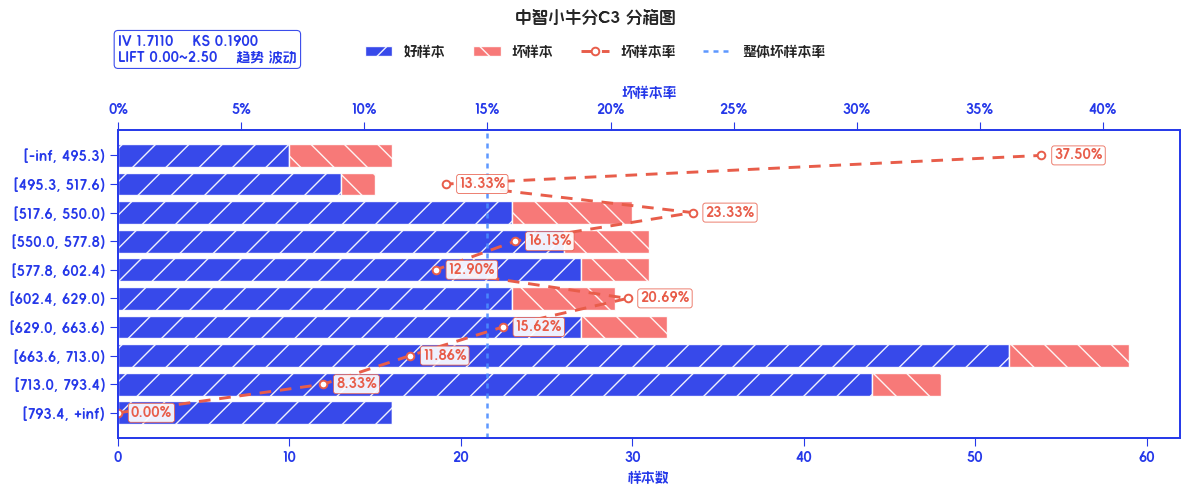

In [3]:
# 特征分箱图
fig = bin_plot(
    df,
    feature='score_c3',
    target='target',
    n_bins=10,
    title='中智小牛分C3 分箱图',
    figsize=(12, 5)
)
plt.show()

In [4]:
# 批量分箱趋势图（单特征逐个绘制）
for feat in numeric_features[:4]:
    fig = bin_trend_plot(
        df,
        feature=feat,
        target='target',
        method='quantile',
        n_bins=5,
        figsize=(14, 4)
    )
    plt.show()

ValueError: n_bins 参数已移除，请使用 max_n_bins

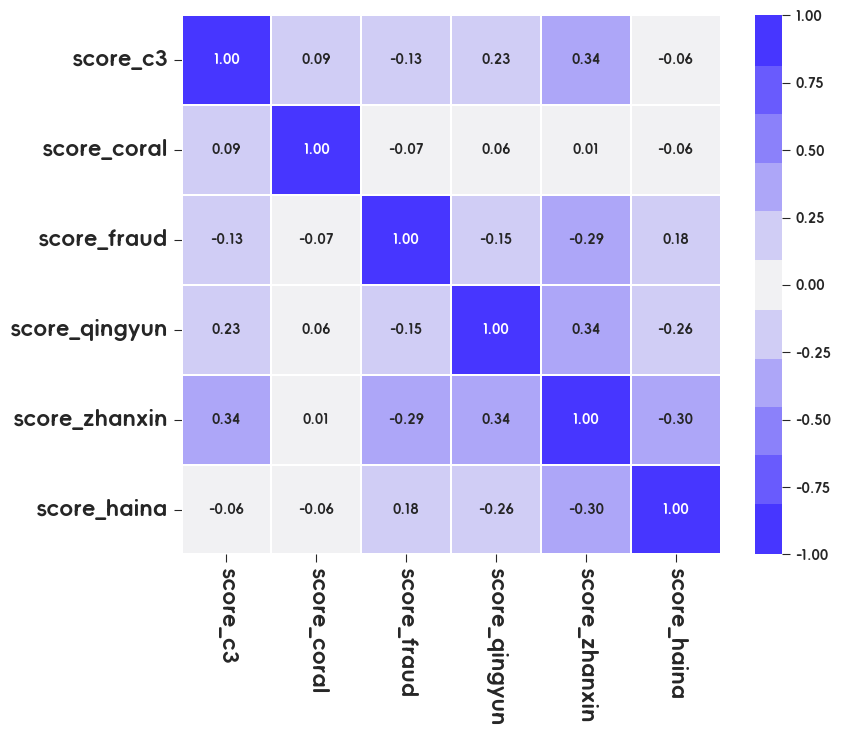

In [5]:
# 特征相关性热力图
fig = corr_plot(
    df[numeric_features[:6]],
    figsize=(9, 7)
)
plt.show()

## 2. 模型评估图

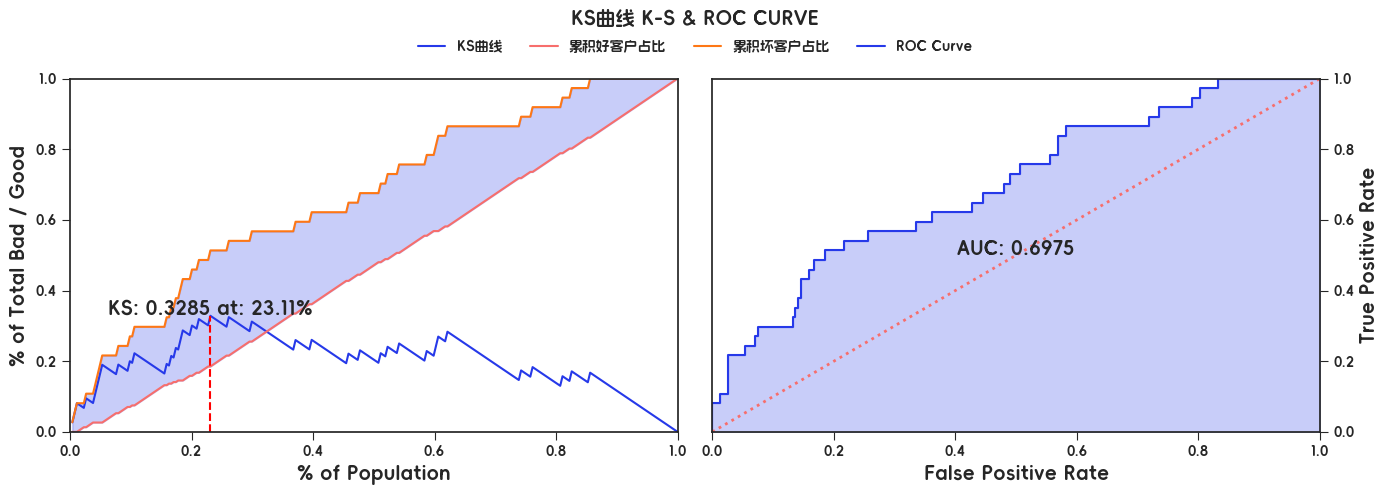

In [6]:
# KS曲线
fig = ks_plot(
    df_model['prob'],
    df_model['target'],
    title='KS曲线',
    figsize=(14, 5)
)
plt.show()

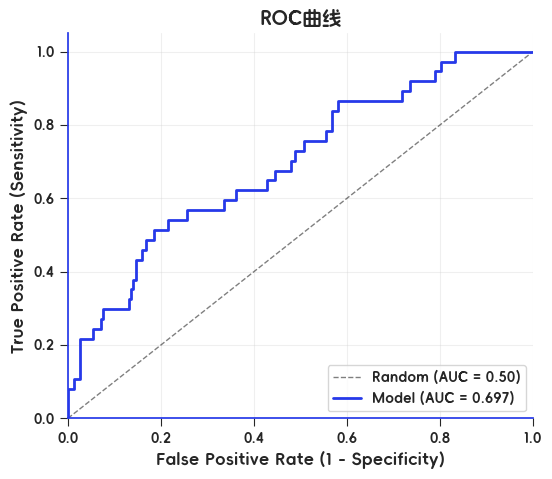

In [7]:
# ROC曲线
fig = roc_plot(
    df_model['target'],
    df_model['prob'],
    title='ROC曲线',
    figsize=(6, 5)
)
plt.show()

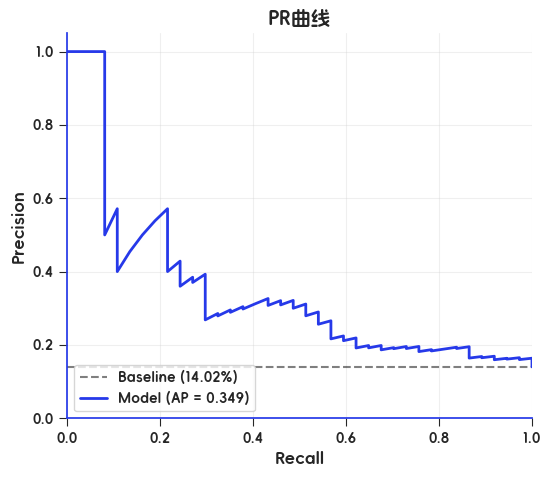

In [8]:
# PR曲线
fig = pr_plot(
    df_model['target'],
    df_model['prob'],
    title='PR曲线',
    figsize=(6, 5)
)
plt.show()

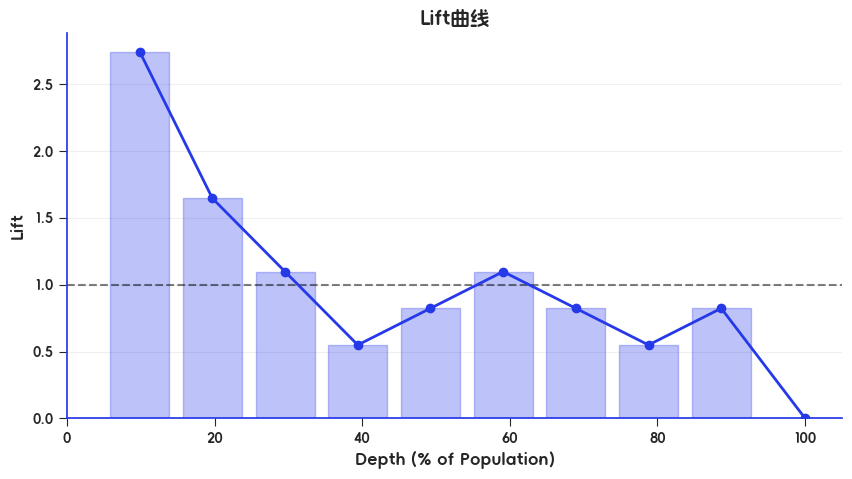

In [9]:
# Lift曲线
fig = lift_plot(
    df_model['target'],
    df_model['prob'],
    title='Lift曲线',
    figsize=(10, 5)
)
plt.show()

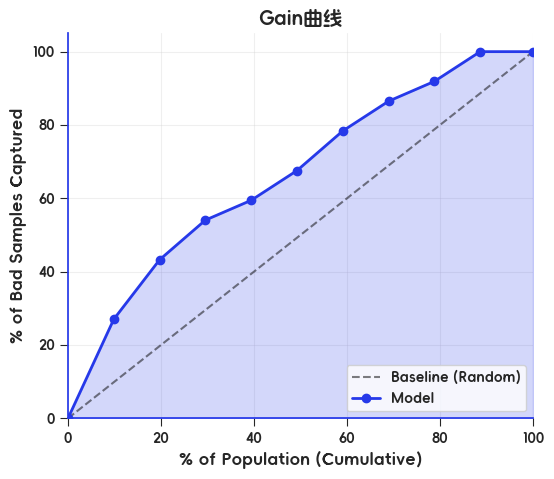

In [10]:
# Gain曲线
fig = gain_plot(
    df_model['target'],
    df_model['prob'],
    title='Gain曲线',
    figsize=(6, 5)
)
plt.show()

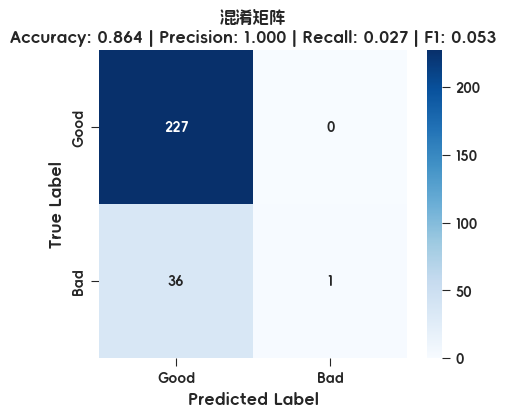

In [11]:
# 混淆矩阵
y_pred = (df_model['prob'] > 0.5).astype(int)
fig = confusion_matrix_plot(
    df_model['target'],
    y_pred,
    title='混淆矩阵',
    figsize=(5, 4)
)
plt.show()

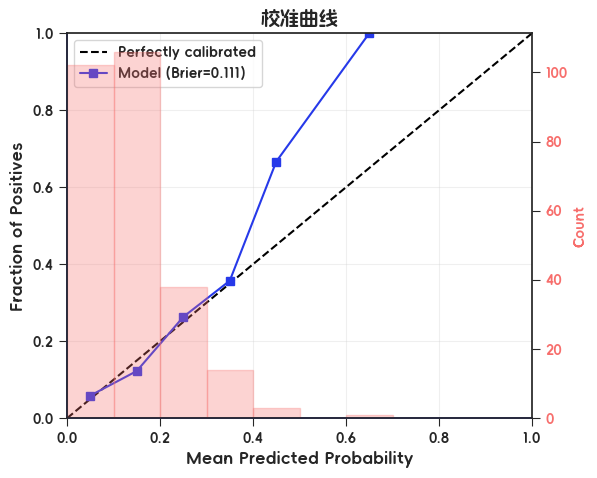

In [12]:
# 校准曲线
fig = calibration_plot(
    df_model['target'],
    df_model['prob'],
    title='校准曲线',
    figsize=(6, 5)
)
plt.show()

## 3. 分布图

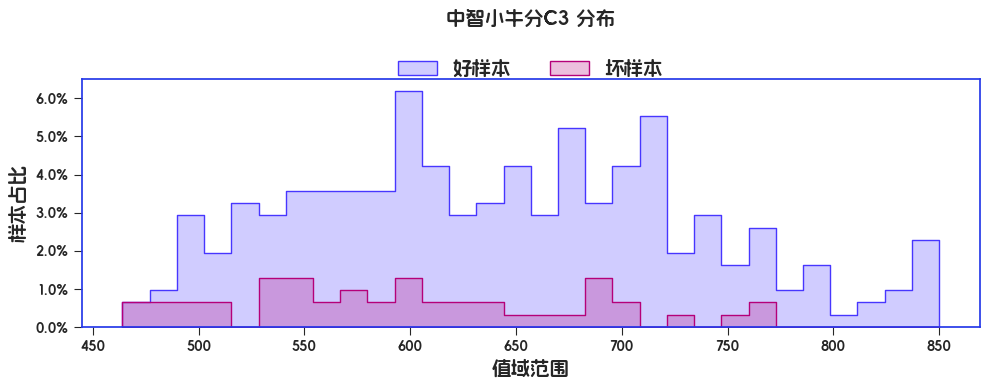

In [13]:
# 特征分布（按好坏样本分色）
fig = hist_plot(
    df['score_c3'],
    y_true=df['target'],
    title='中智小牛分C3 分布',
    figsize=(10, 4),
)
plt.show()

In [14]:
# PSI稳定性图
np.random.seed(42)
score_train = np.random.normal(650, 80, 500)
score_test = np.random.normal(640, 85, 300)
fig = psi_plot(
    score_train,
    score_test,
    n_bins=10,
    title='PSI稳定性图',
    figsize=(10, 4)
)
plt.show()

TypeError: psi_plot() got an unexpected keyword argument 'n_bins'

In [15]:
# 时间分布图
df['loan_month'] = pd.to_datetime(df['放款时间']).dt.to_period('M').astype(str)
fig = distribution_plot(
    df,
    date_col='放款时间',
    feature='score_c3',
    title='评分时间分布',
    figsize=(12, 4)
)
plt.show()

TypeError: distribution_plot() got an unexpected keyword argument 'date_col'

## 4. 评分分析图

KeyError: "None of [Int64Index([0, 0, 0, 0, 0, 0, 1, 0, 0, 0,\n            ...\n            0, 0, 0, 0, 0, 0, 0, 1, 0, 0],\n           dtype='int64', length=264)] are in the [index]"

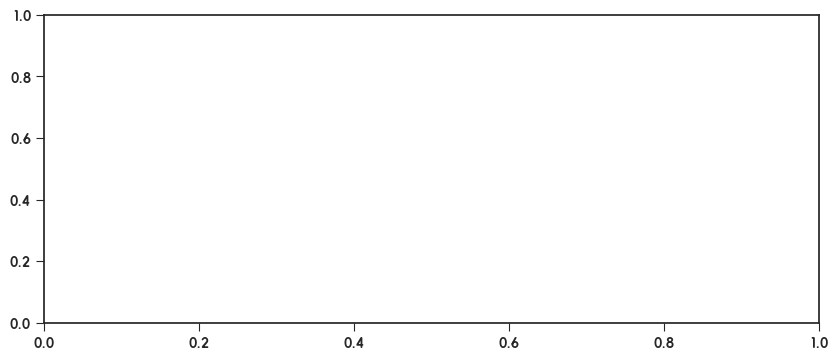

In [16]:
# 评分分布图
fig = score_dist_plot(
    df_model['prob'],
    df_model['target'],
    title='评分分布（好坏样本对比）',
    figsize=(10, 4)
)
plt.show()

In [17]:
# 评分分箱效果图
fig = score_bin_plot(
    df_model['prob'],
    df_model['target'],
    n_bins=10,
    title='评分分箱效果',
    figsize=(10, 4)
)
plt.show()

TypeError: score_bin_plot() missing 1 required positional argument: 'target_col'

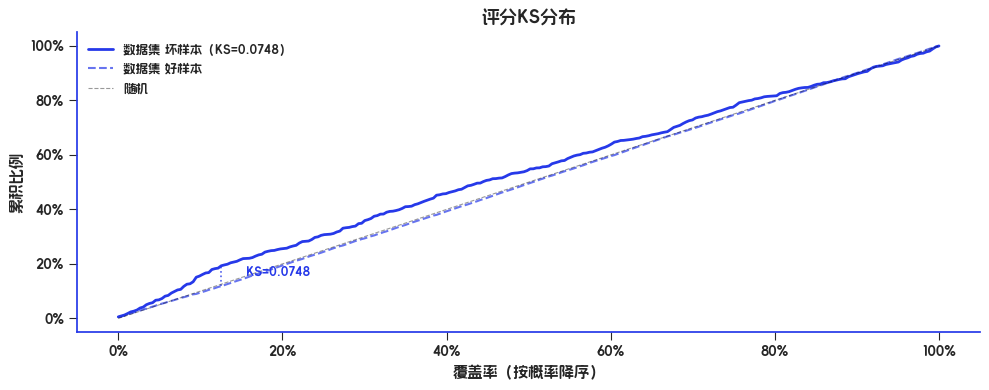

In [18]:
# 评分KS图
fig = score_ks_plot(
    df_model['prob'],
    df_model['target'],
    n_bins=20,
    title='评分KS分布',
    figsize=(10, 4)
)
plt.show()

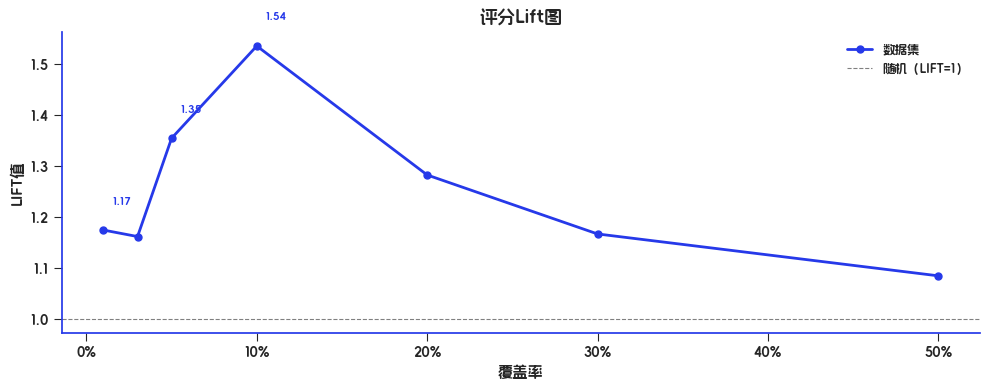

In [19]:
# 评分Lift图
fig = score_lift_plot(
    df_model['prob'],
    df_model['target'],
    title='评分Lift图',
    figsize=(10, 4)
)
plt.show()

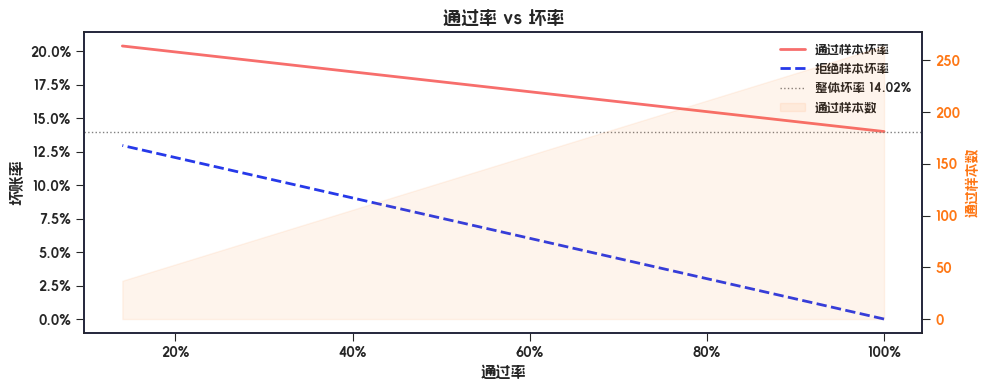

In [20]:
# 评分通过率vs坏率曲线
fig = score_approval_badrate_curve(
    df_model['prob'],
    df_model['target'],
    title='通过率 vs 坏率',
    figsize=(10, 4)
)
plt.show()

## 5. 特征分析图

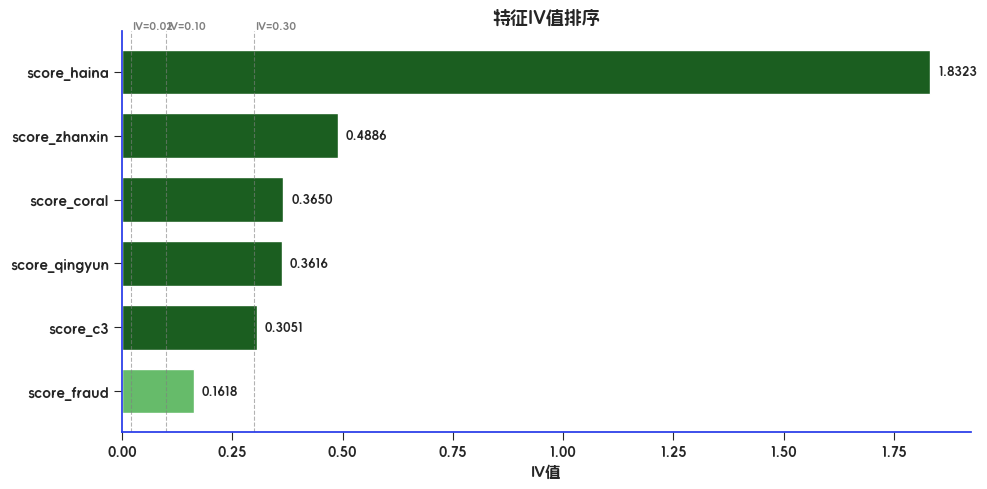

In [21]:
# 特征IV值柱状图
fig = variable_iv_plot(
    df[numeric_features + ['target']].dropna(),
    features=numeric_features[:6],
    target='target',
    title='特征IV值排序',
    figsize=(10, 5)
)
plt.show()

In [22]:
# WOE趋势图
fig = variable_woe_trend_plot(
    df,
    feature='score_c3',
    target='target',
    n_bins=10,
    title='中智小牛分C3 WOE趋势',
    figsize=(10, 4)
)
plt.show()

ValueError: bin_table 必须含 WOE 和坏样本率列

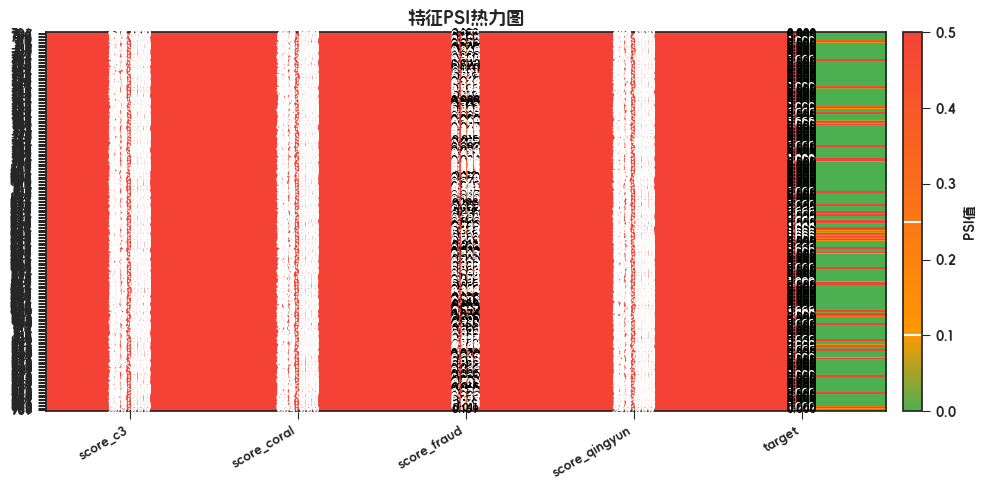

In [23]:
# 特征PSI热力图（多特征批量）
fig = variable_psi_heatmap(
    df[numeric_features[:4] + ['target']].dropna(),
    features=numeric_features[:4],
    target='target',
    n_bins=5,
    title='特征PSI热力图',
    figsize=(10, 5)
)
plt.show()

In [24]:
# 特征重要性图
fig = feature_importance_plot(
    lr,
    feature_names=numeric_features,
    title='逻辑回归特征重要性',
    figsize=(10, 5)
)
plt.show()

TypeError: feature_importance_plot() missing 1 required positional argument: 'importance'

## 6. 策略图

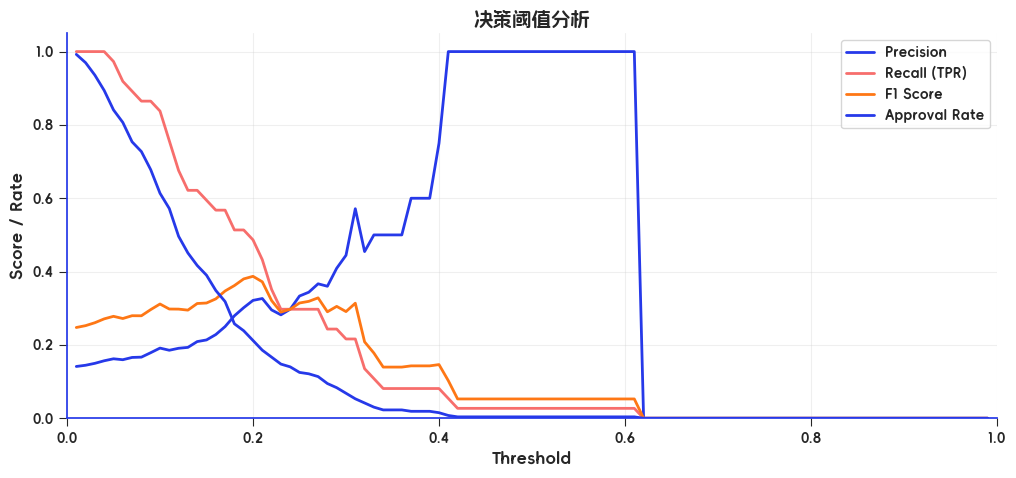

In [25]:
# 决策阈值分析
fig = threshold_analysis_plot(
    df_model['target'],
    df_model['prob'],
    title='决策阈值分析',
    figsize=(12, 5)
)
plt.show()

In [26]:
# 策略对比图
fig = strategy_compare_plot(
    df_model['prob'],
    df_model['target'],
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
    labels=['阈值0.3', '阈值0.4', '阈值0.5', '阈值0.6', '阈值0.7'],
    title='多阈值策略对比',
    figsize=(12, 5)
)
plt.show()

AttributeError: 'Series' object has no attribute 'figure'

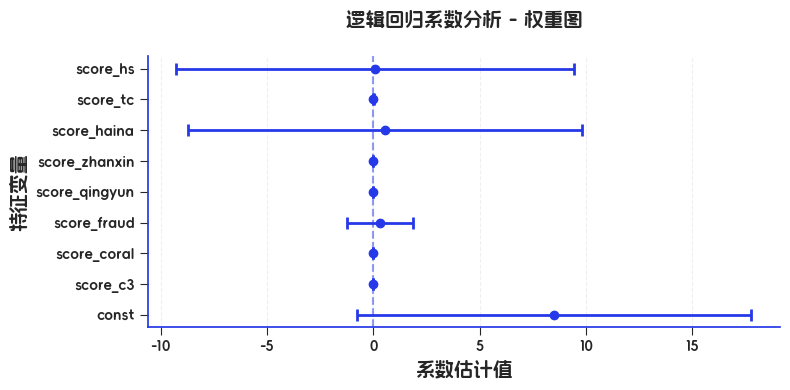

In [27]:
# 系数权重图
from hscredit.core.viz import plot_weights
fig = plot_weights(lr, figsize=(8, 4))
plt.show()

## 7. 样式工具

In [28]:
# 查看可用的配色方案
print("PRIMARY_COLORS:", PRIMARY_COLORS)
print("\n可用配色:", list(get_palette().keys()) if hasattr(get_palette(), 'keys') else get_palette())

PRIMARY_COLORS: ['#2639E9', '#F76E6C', '#FE7715']

可用配色: ['#2639E9', '#F76E6C', '#FE7715']
